In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib

print("Libraries loaded")

Libraries loaded


In [2]:
class CowTwin:
    """
    Digital Twin for a single animal.
    Maintains virtual health state updated by 
    behavior classifier and anomaly detector.
    """
    
    def __init__(self, animal_id, baseline):
        self.animal_id  = animal_id
        self.baseline   = baseline
        self.state      = 'NORMAL'
        self.history    = []
        
        # Consecutive anomaly counter
        # state only changes after sustained anomalies
        self.anomaly_streak = 0
        self.ALERT_THRESHOLD   = 3   # 3 consecutive anomalies = AT_RISK
        self.CRITICAL_THRESHOLD = 8  # 8 consecutive anomalies = ALERT
    
    def update(self, timestamp, features, 
               anomaly_score, is_anomaly, predicted_behavior):
        """
        Update twin state with one new 30-second window.
        """
        # Update anomaly streak
        if is_anomaly:
            self.anomaly_streak += 1
        else:
            self.anomaly_streak = 0
        
        # State transition logic
        if self.anomaly_streak >= self.CRITICAL_THRESHOLD:
            self.state = 'ALERT'
        elif self.anomaly_streak >= self.ALERT_THRESHOLD:
            self.state = 'AT_RISK'
        else:
            self.state = 'NORMAL'
        
        # Record this update
        record = {
            'timestamp':          timestamp,
            'predicted_behavior': predicted_behavior,
            'anomaly_score':      anomaly_score,
            'is_anomaly':         is_anomaly,
            'anomaly_streak':     self.anomaly_streak,
            'state':              self.state,
        }
        self.history.append(record)
    
    def get_history_df(self):
        return pd.DataFrame(self.history)
    
    def summary(self):
        h = self.get_history_df()
        print(f"\n=== Digital Twin Summary: {self.animal_id} ===")
        print(f"  Current state:    {self.state}")
        print(f"  Total windows:    {len(h):,}")
        print(f"  Anomaly windows:  {h['is_anomaly'].sum():,} ({h['is_anomaly'].mean()*100:.1f}%)")
        print(f"  Max streak:       {h['anomaly_streak'].max()}")
        print(f"  ALERT events:     {(h['state']=='ALERT').sum():,}")
        print(f"  AT_RISK events:   {(h['state']=='AT_RISK').sum():,}")
        print(f"\n  Predicted behavior distribution:")
        for b, count in h['predicted_behavior'].value_counts().items():
            print(f"    {b:12s}: {count:6,} ({count/len(h)*100:.1f}%)")

print("CowTwin class defined")

CowTwin class defined


In [3]:
# Load models
rf           = joblib.load('../models/rf_classifier.joblib')
iso_forest   = joblib.load('../models/isolation_forest.joblib')
scaler       = joblib.load('../models/scaler.joblib')
feature_cols = joblib.load('../models/feature_cols.joblib')
baselines    = joblib.load('../models/baselines.joblib')

# Load scored test data
cow04_scored = pd.read_csv('../data/cow04_scored.csv')
cow04_scored['window_start'] = pd.to_datetime(cow04_scored['window_start'])

# Load train windows for twin profiles
train = pd.read_csv('../data/windows_train.csv')

print(f"Loaded {len(cow04_scored):,} windows for cow_04")
print("Simulating real-time streaming through cow_04 data...")

Loaded 16,867 windows for cow_04
Simulating real-time streaming through cow_04 data...


In [4]:
# Create twin for cow_04
twin_04 = CowTwin(
    animal_id='cow_04',
    baseline=baselines['cow_04']
)

# Simulate streaming: feed one window at a time
X_scaled = scaler.transform(cow04_scored[feature_cols])
predicted_behaviors = rf.predict(cow04_scored[feature_cols])

for i, row in cow04_scored.iterrows():
    idx = cow04_scored.index.get_loc(i)
    
    twin_04.update(
        timestamp=row['window_start'],
        features=row[feature_cols].values,
        anomaly_score=row['anomaly_score'],
        is_anomaly=row['is_anomaly'],
        predicted_behavior=predicted_behaviors[idx]
    )

twin_04.summary()


=== Digital Twin Summary: cow_04 ===
  Current state:    NORMAL
  Total windows:    16,867
  Anomaly windows:  2,481 (14.7%)
  Max streak:       37
  ALERT events:     582
  AT_RISK events:   711

  Predicted behavior distribution:
    Other       :  7,068 (41.9%)
    Ruminating  :  5,574 (33.0%)
    Eating      :  4,225 (25.0%)


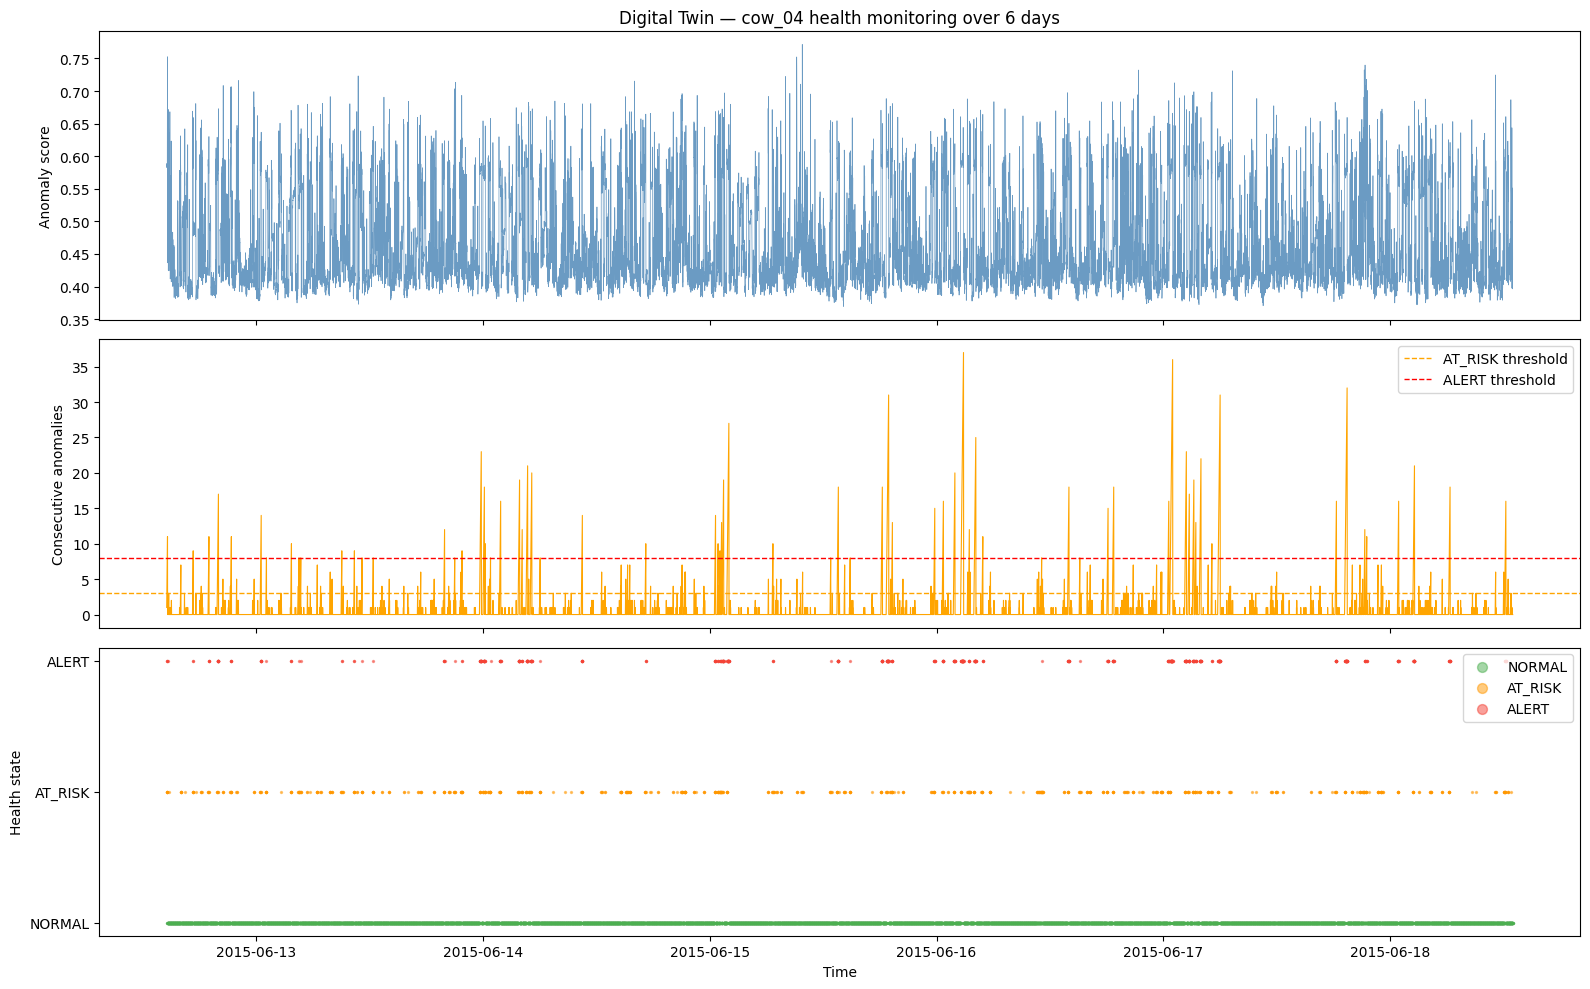

In [5]:
history = twin_04.get_history_df()
history['timestamp'] = pd.to_datetime(history['timestamp'])

state_colors = {'NORMAL': '#4CAF50', 'AT_RISK': '#FF9800', 'ALERT': '#F44336'}
state_num    = {'NORMAL': 0, 'AT_RISK': 1, 'ALERT': 2}
history['state_num'] = history['state'].map(state_num)

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Top: anomaly score
axes[0].plot(history['timestamp'], history['anomaly_score'],
             color='steelblue', linewidth=0.5, alpha=0.8)
axes[0].set_ylabel('Anomaly score')
axes[0].set_title('Digital Twin — cow_04 health monitoring over 6 days')

# Middle: anomaly streak
axes[1].plot(history['timestamp'], history['anomaly_streak'],
             color='orange', linewidth=0.8)
axes[1].axhline(twin_04.ALERT_THRESHOLD,    color='orange', 
                linestyle='--', linewidth=1, label='AT_RISK threshold')
axes[1].axhline(twin_04.CRITICAL_THRESHOLD, color='red',    
                linestyle='--', linewidth=1, label='ALERT threshold')
axes[1].set_ylabel('Consecutive anomalies')
axes[1].legend(loc='upper right')

# Bottom: health state
for state, color in state_colors.items():
    mask = history['state'] == state
    axes[2].scatter(history[mask]['timestamp'],
                    history[mask]['state_num'],
                    c=color, s=2, alpha=0.5, label=state)

axes[2].set_yticks([0, 1, 2])
axes[2].set_yticklabels(['NORMAL', 'AT_RISK', 'ALERT'])
axes[2].set_ylabel('Health state')
axes[2].set_xlabel('Time')
axes[2].legend(loc='upper right', markerscale=5)

plt.tight_layout()
plt.savefig('../data/twin_state_timeline.png', dpi=100)
plt.show()

In [6]:
history.to_csv('../data/twin_cow04_history.csv', index=False)
print("Twin history saved to ../data/twin_cow04_history.csv")
print(f"\nFinal state of cow_04 twin: {twin_04.state}")

Twin history saved to ../data/twin_cow04_history.csv

Final state of cow_04 twin: NORMAL
